In [1]:
#Dependencies to download
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split as tts

In [54]:
#Synthetic Dataset
def generate_dataset(num_samples=14000):
    """
    Generate 50x50 grayscale images with exactly one active pixel of 255.
    Target is (x, y) coordinate of that active pixel.
    Total generated images are 14000
    """
    images = np.zeros((num_samples, 50, 50, 1), dtype=np.float32)
    labels = np.zeros((num_samples, 2), dtype=np.float32)

    for i in range(num_samples):
        x = np.random.randint(0, 50)
        y = np.random.randint(0, 50)

        # Initializing one random pixel with 255
        images[i, x, y, 0] = 255.0

        labels[i] = [x, y]  

    return images, labels


In [55]:
images, labels = generate_dataset(14000)

X_train, X_temp, y_train, y_temp = tts(
    images, labels, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = tts(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (9800, 50, 50, 1)
Validation: (2100, 50, 50, 1)
Test: (2100, 50, 50, 1)


In [56]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(
            16, (3, 3),
            activation='relu',
            padding='same',
            input_shape=(50, 50, 1)
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(
            32, (3, 3),
            activation='relu',
            padding='same'
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(2, activation='linear')  # Coordinate output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model


In [61]:
model.summary()
#The model summary shows the layers and pooling used in the CNN architecture. 

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 50, 50, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 25, 25, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 25, 25, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,785,032 (6.81 MB)

 Trainable params: 595,010 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,190,022 (4.54 MB)

In [57]:
model = build_model()
#Using early stopping to prevent model from overfitting and store best weights of the model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(X_train,y_train,validation_data=(X_val, y_val),epochs=20,batch_size=64,callbacks=[early_stop])


Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 30.2921 - mae: 2.6933 - val_loss: 1.6910 - val_mae: 0.8710
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 1.1126 - mae: 0.7060 - val_loss: 0.5756 - val_mae: 0.5496
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.5630 - mae: 0.5395 - val_loss: 0.4375 - val_mae: 0.4954
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.4360 - mae: 0.4830 - val_loss: 0.4167 - val_mae: 0.4574
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.3412 - mae: 0.4202 - val_loss: 0.2769 - val_mae: 0.3969
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.4391 - mae: 0.4753 - val_loss: 0.3556 - val_mae: 0.4558
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.3903 - mae: 0.4607 - val_loss: 0.4799 - val_mae: 0.5077
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 0.5622 - mae: 0.5487 - val_loss: 0.5371 - val_mae: 0.5236


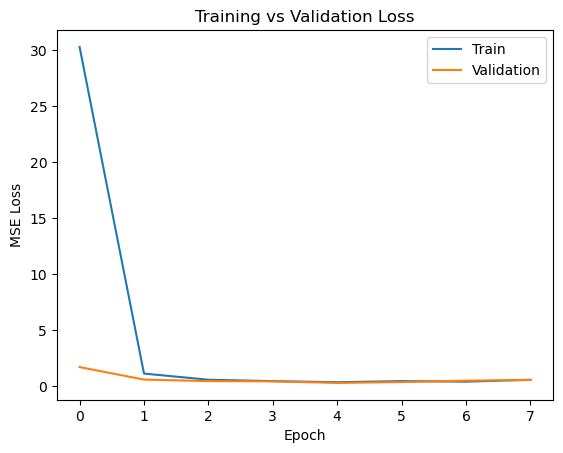

In [58]:
#Plotting graphs between training and validation to ensure model is performing well or is going any situation of overfitting or underfitting
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train", "Validation"])
plt.show()


In [59]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MSE:", test_loss)
print("Test MAE (pixel error):", test_mae)


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2964 - mae: 0.4072
Test MSE: 0.29637786746025085
Test MAE (pixel error): 0.4071710407733917


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


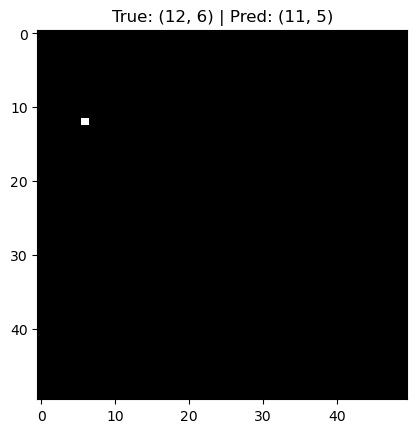

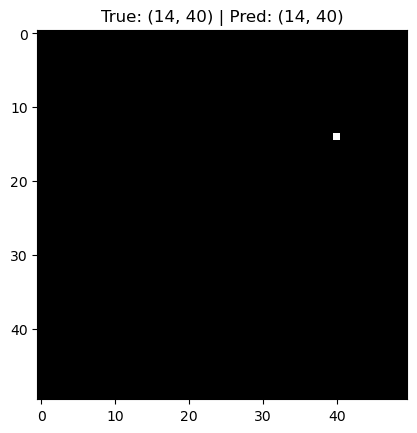

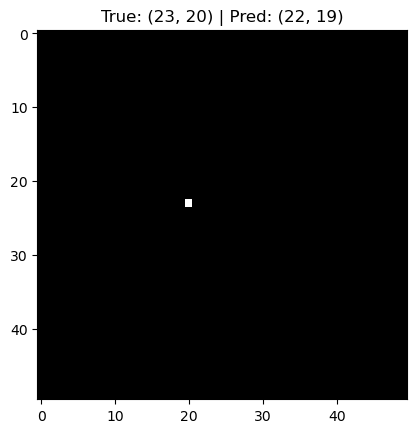

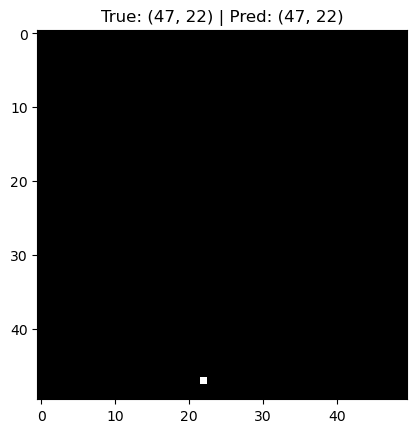

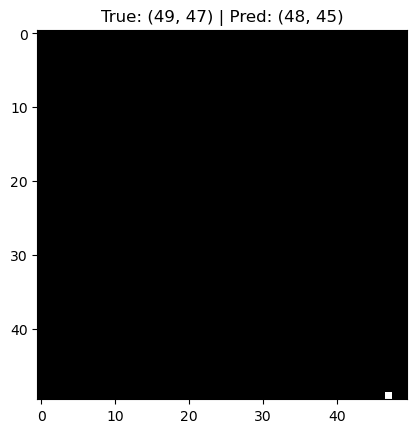

In [60]:
# Visualizing true labels and predicted labels 
def visualize_predictions(model, X_test, y_test, num_samples=5):
    preds = model.predict(X_test[:num_samples])

    for i in range(num_samples):
        img = X_test[i].squeeze()
        true_x, true_y = y_test[i]
        pred_x, pred_y = preds[i]

        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.title(
            f"True: ({int(true_x)}, {int(true_y)}) | "
            f"Pred: ({int(pred_x)}, {int(pred_y)})"
        )
        plt.show()


visualize_predictions(model, X_test, y_test)
